In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, random_split
import seaborn as sns

In [73]:
import importlib
import v2_utils
import generators
import autoencoders
importlib.reload(v2_utils)
importlib.reload(autoencoders)
from v2_utils import CSVDataLoader, ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator
from autoencoders import RecurrentAutoencoder
N_DV = 20

In [5]:

batch_size = 32
window_size = 30
input_dim = 50

model = RecurrentAutoencoder(
    input_dim=input_dim,
    window_size=window_size,
    hidden_dim=128,
    latent_dim=32,
    num_layers=2,
    rnn_type="GRU"
)

x = torch.randn(batch_size, window_size, input_dim)

reconstructed, latent = model(x)

print(f"Вход: {x.shape}")
print(f"Выход: {reconstructed.shape}")
print(f"Скрытое представление: {latent.shape}")

loss = F.mse_loss(reconstructed, x)
print(f"MSE loss: {loss.item():.4f}")

Вход: torch.Size([32, 30, 50])
Выход: torch.Size([32, 30, 50])
Скрытое представление: torch.Size([32, 32])
MSE loss: 1.0078


In [ ]:
data_gen = CSVDataLoader("./gen_data_new/gen_data_0", 
                         # file_fraction=0.05,
                         max_samples=100000, 
                         # normal_dir="./gen_data/gen_data_0", 
                         normalize=True
                    )
X, y = data_gen.get_full_data(window=window_size)
X = X[~y]
print(X.shape)
#  сделать проверку на наличие
path = "./windows/new_0.npz"
np.savez_compressed(path, X=X)
del X, y, data_gen


In [10]:

def load_npz_data(file_path):
    data = np.load(file_path)
    # (n_samples, seq_len, n_features), 'y': (n_samples,)
    X = data['X'].astype(np.float32)
    y = data['y'].astype(np.int64) if 'y' in data else None
    return X, y


def create_dataloaders(
    file_path,
    batch_size=32
):
    data = np.load(file_path)
    X = data['X'].astype(np.float32)

    X_train, X_test = train_test_split(X, test_size=0.3, shuffle=False, random_state=42)
    print(f"{X_train.shape=}, {X_test.shape=}")
    train_dataset = TensorDataset(torch.FloatTensor(X_train))
    test_dataset = TensorDataset(torch.FloatTensor(X_test))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

In [11]:

def train_autoencoder(model, train_loader, test_loader, epochs=50, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            X = batch[0].to(device)
            
            optimizer.zero_grad()
            reconstructed, _ = model(X)
            loss = criterion(reconstructed, X)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(X)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                X = batch[0].to(device)
                reconstructed, _ = model(X)
                loss = criterion(reconstructed, X)
                test_loss += loss.item() * len(X)
        
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)
        
        # if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs}: Train MSE: {train_loss:.6f}, Test MSE: {test_loss:.6f}')
    
    return train_losses, test_losses

In [37]:
batch_size = 16
epochs = 50
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

path = "./windows/new_0.npz"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size)

model = RecurrentAutoencoder(
    input_dim=53,
    window_size=window_size,
    hidden_dim=64,
    latent_dim=32,
    num_layers=1
)

train_losses, test_losses = train_autoencoder(
    model, train_loader, test_loader, 
    epochs=epochs, device=device
)
print(f'Final Train MSE: {train_losses[-1]:.6f}')
print(f'Final Test MSE: {test_losses[-1]:.6f}')

model.to("cpu")
model_saved_path = "./models/new_autoencoder_w30.pth"
torch.save(model.state_dict(), model_saved_path)


Device:  cuda:1
X_train.shape=(70000, 30, 53), X_test.shape=(30000, 30, 53)
Epoch 1/50: Train MSE: 0.687586, Test MSE: 0.651842
Epoch 2/50: Train MSE: 0.653536, Test MSE: 0.640687
Epoch 3/50: Train MSE: 0.642827, Test MSE: 0.640025
Epoch 4/50: Train MSE: 0.636448, Test MSE: 0.629721
Epoch 5/50: Train MSE: 0.627068, Test MSE: 0.608622
Epoch 6/50: Train MSE: 0.612128, Test MSE: 0.604525
Epoch 7/50: Train MSE: 0.606692, Test MSE: 0.597460
Epoch 8/50: Train MSE: 0.601807, Test MSE: 0.593726
Epoch 9/50: Train MSE: 0.598059, Test MSE: 0.587056
Epoch 10/50: Train MSE: 0.592995, Test MSE: 0.586124
Epoch 11/50: Train MSE: 0.592065, Test MSE: 0.584028
Epoch 12/50: Train MSE: 0.591659, Test MSE: 0.584253
Epoch 13/50: Train MSE: 0.590963, Test MSE: 0.585286
Epoch 14/50: Train MSE: 0.590297, Test MSE: 0.585123
Epoch 15/50: Train MSE: 0.589774, Test MSE: 0.584545
Epoch 16/50: Train MSE: 0.589170, Test MSE: 0.584092
Epoch 17/50: Train MSE: 0.589087, Test MSE: 0.585380
Epoch 18/50: Train MSE: 0.588592

Final Train MSE: 0.575709
Final Test MSE: 0.573412


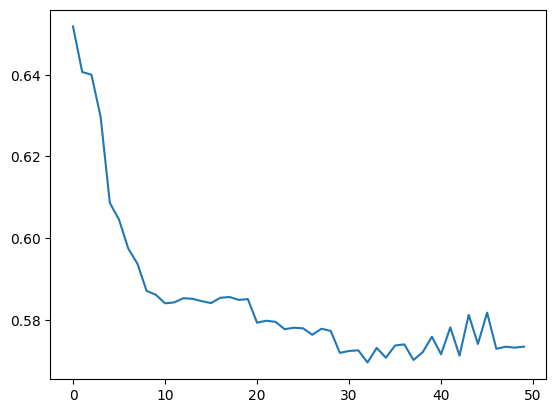

In [38]:
plt.plot(test_losses)
print(f'Final Train MSE: {train_losses[-1]:.6f}')
print(f'Final Test MSE: {test_losses[-1]:.6f}')


Загрузка (TODO - сделать параметризуемой структуру)

In [ ]:
the_model = RecurrentAutoencoder(
        input_dim=53,
        window_size=100,
        hidden_dim=128,
        latent_dim=32,
        num_layers=1
    )
model_saved_path = "./models/autoencoder.pth"
the_model.load_state_dict(torch.load(model_saved_path))


(47315, 100, 53)
(47315, 32)


<Axes: >

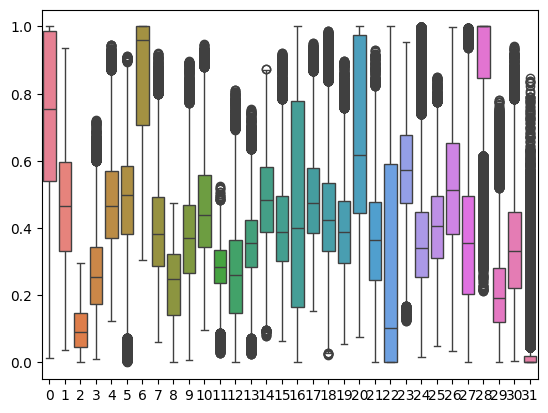

In [57]:
X0, y = load_npz_data("./windows/0.npz")
print(X0.shape)
X0 = torch.FloatTensor(X0)
model.to("cpu")
model.eval()
enc = model.encode(X0).detach().cpu().numpy()
print(enc.shape)
df = pd.DataFrame(enc)
sns.boxplot(data=df)

In [80]:
data_gen = CSVDataLoader("./gen_data_new/gen_data_1", 
                         file_fraction=0.03,
                         max_samples=100000, 
                         anomaly_ratio=0.11,
                         normal_dir="./gen_data_new/gen_data_0", 
                         normalize=False,
                         verbose=True
                    )
X, y = data_gen.get_full_data()
# X = X[~y]
print(X.shape, y.shape, y.mean())


0.03
0: sum(self.normal_sizes)=5000000
0.0183658
1: sum(self.normal_sizes)=92000
0.7185978260869565
2: sum(self.normal_sizes)=66500
files sizes: 8171
normal sizes: 66500
   Итого: X.shape=(74671, 53), y.shape=(74671,)
   Доля аномалий: 0.0723
(74671, 53) (74671,) 0.07231723158923813


In [71]:
data_gen.sizes

[404, 490, 456, 491, 427, 474, 425, 482, 441, 435, 495, 474]